# 01. 문제 정의와 데이터 (Hourly Dam Operation)

이 시리즈는 `tutorial_nbs/` 의 일 단위 튜토리얼을 **시간 단위(hourly) 댐 운영 의사결정**으로 확장한 것입니다. 운영기관의 요구사항은 다음과 같습니다.

| # | 요구사항 | 구현 위치 |
|---|---|---|
| 1 | 제약 우선순위: **홍수 > 가뭄 > 기타**. 발전보다 우선 | 마스크 우선순위(§4), 두 개의 라그랑주 승수(노트북 03) |
| 2 | **발전은 제약이 아님** | 발전은 보상의 작은 항(`w_energy=0.05`)일 뿐, 비용/마스크에 없음 |
| 3 | 입력: 댐수위, 하류 주요지점 홍수량, 기상예측 기반 댐유입량 | 관측 벡터 19차원(§5) |
| 4 | 매월 1일 기준 **상한·하한 운영수위**, 그 안에서 운영 | `UPPER_GUIDE`, `LOWER_GUIDE` 를 날짜로 보간(§3) |
| 5 | 운영자가 **상한 근처 / 중간 / 하한 근처** 를 선택 | `target_position ∈ [0,1]` 을 정책 입력으로 조건화 |
| 6 | **3일(72h) hourly 홍수예측**, 이후 일 단위 예측으로 연간 안정성 검토 | `make_forecasts()`: 72h hourly + 7일 daily (§6), 노트북 05 |

모든 수치는 합성(synthetic)이며 중규모 다목적댐을 느슨하게 모사합니다. 실제 적용 시 교체할 데이터는 마지막 절에 정리했습니다.

In [1]:
import sys, numpy as np, pandas as pd, matplotlib.pyplot as plt
sys.path.insert(0, ".")
import hourly_reservoir as hr
plt.rcParams["figure.figsize"] = (12, 3.4)

## 1. 댐 제원과 수위–저수량 곡선

사수위 110 m, 계획홍수위 123 m(절대 상한), 댐마루 125 m. 저수량은 표(`LEVEL_TABLE`, `STORAGE_TABLE`)를 선형 보간합니다.

,0,1,2,3,4,5,6,7
level_m,105.0,110.0,113.0,116.0,119.0,121.0,123.0,125.0
storage_1e6m3,40.0,150.0,260.0,410.0,600.0,760.0,950.0,1150.0


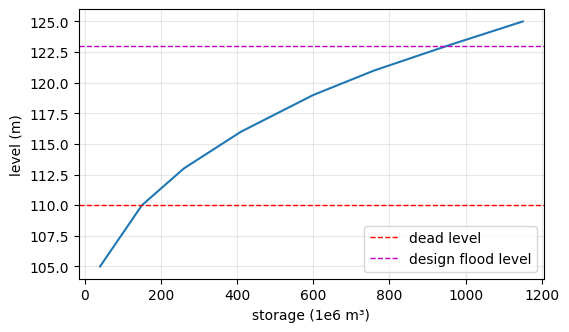

In [2]:
z = np.linspace(105, 125, 200)
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(hr.storage_from_level(z), z); ax.axhline(hr.Z_DEAD, c="r", ls="--", lw=1, label="dead level"); ax.axhline(hr.Z_DESIGN_FLOOD, c="m", ls="--", lw=1, label="design flood level")
ax.set_xlabel("storage (1e6 m³)"); ax.set_ylabel("level (m)"); ax.legend(); ax.grid(alpha=.3)
pd.DataFrame({"level_m": hr.LEVEL_TABLE, "storage_1e6m3": hr.STORAGE_TABLE}).T

## 2. 방류 제원과 하류 제약

| 항목 | 값 | 의미 |
|---|---|---|
| `Q_MIN`–`Q_MAX` | 5–3000 m³/s | 총 방류 범위 |
| `Q_TURBINE_MAX` | 300 m³/s | 발전 방류 상한(발전은 제약 아님) |
| `Q_ENV_MIN` | 15 m³/s | 하천유지유량(가뭄 제약) |
| `Q_DS_SAFE` | 2500 m³/s | 하류 주요지점 계획홍수량(홍수 제약) |
| `RAMP_MAX` | 300 m³/s/h | 시간당 방류 변화 한도 |
| `LATERAL_RATIO`, `ROUTING_LAG_H` | 0.35, 3 h | 댐–주요지점 사이 지류 유입, 도달시간 |

## 3. 월별 운영수위 (요구사항 4)

매월 1일의 상한·하한 운영수위를 정의하고, 그 사이는 선형 보간합니다. 홍수기(6–9월)에는 상한이 낮아져 홍수조절용량을 확보하고, 10월부터 담수합니다.

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
upper_guide_m,118.0,118.0,118.0,117.5,117.0,115.0,114.0,114.0,116.0,118.0,118.5,118.0
lower_guide_m,112.0,111.5,111.0,111.0,111.0,111.0,111.0,111.0,111.5,112.0,112.5,112.5


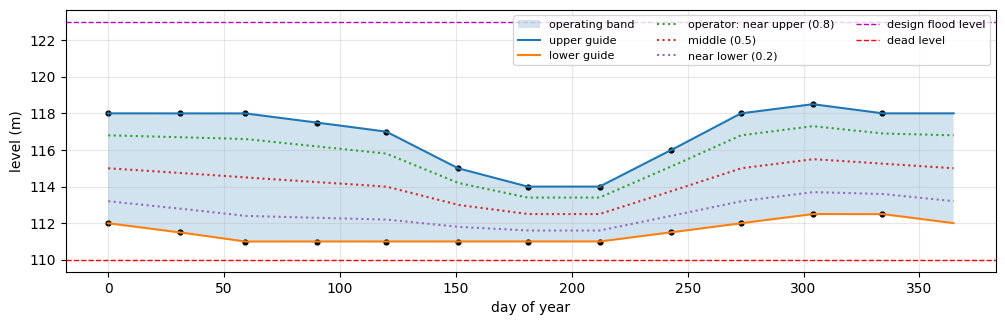

In [3]:
months = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
tbl = pd.DataFrame({"upper_guide_m": hr.UPPER_GUIDE, "lower_guide_m": hr.LOWER_GUIDE}, index=months)
doy = np.arange(0, 365, 0.25)
band = np.array([hr.guide_levels(d) for d in doy])
fig, ax = plt.subplots()
ax.fill_between(doy, band[:,1], band[:,0], alpha=.2, label="operating band")
ax.plot(doy, band[:,0], label="upper guide"); ax.plot(doy, band[:,1], label="lower guide")
for tp, lab in [(0.8, "operator: near upper (0.8)"), (0.5, "middle (0.5)"), (0.2, "near lower (0.2)")]:
    ax.plot(doy, band[:,1] + tp * (band[:,0] - band[:,1]), ls=":", label=lab)
ax.scatter(hr.MONTH_START_DOY, hr.UPPER_GUIDE, c="k", s=12); ax.scatter(hr.MONTH_START_DOY, hr.LOWER_GUIDE, c="k", s=12)
ax.axhline(hr.Z_DESIGN_FLOOD, c="m", ls="--", lw=1, label="design flood level"); ax.axhline(hr.Z_DEAD, c="r", ls="--", lw=1, label="dead level")
ax.set_xlabel("day of year"); ax.set_ylabel("level (m)"); ax.legend(ncol=3, fontsize=8); ax.grid(alpha=.3)
tbl.T

**운영자 선호(요구사항 5)** 는 `target_position` 하나로 표현합니다. 목표수위 = 하한 + `target_position` × (상한 − 하한). 위 그림의 점선 세 개가 0.8 / 0.5 / 0.2 입니다. 정책은 이 값을 입력으로 받으므로 **하나의 모델**로 세 운영 방식을 모두 지원합니다.

## 4. 합성 시간 단위 유입량

계절 기저유출 + 강우 사상에 의한 홍수 수문곡선(상승 4–10 h, 감수 12–36 h). 장마(7–8월)와 가을 태풍(9월)에 사상이 집중됩니다.

annual mean 126 m³/s | max 16523 m³/s | annual volume 3973 1e6 m³ (reservoir 1150)


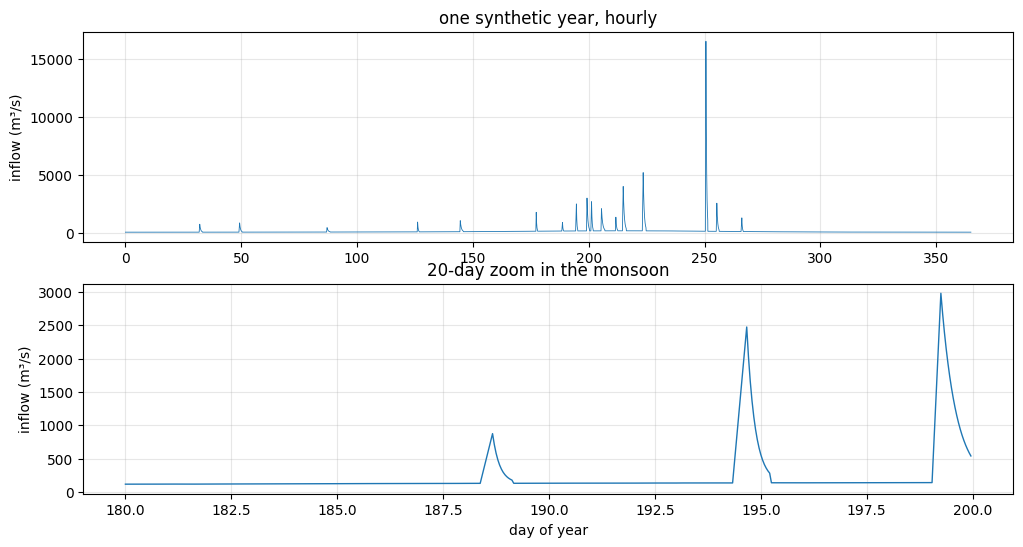

In [4]:
inflow = hr.synthetic_hourly_inflow(8760, seed=3)
t = np.arange(8760) / 24
fig, axes = plt.subplots(2, 1, figsize=(12, 6))
axes[0].plot(t, inflow, lw=.6); axes[0].set_ylabel("inflow (m³/s)"); axes[0].set_title("one synthetic year, hourly")
axes[1].plot(t[180*24:200*24], inflow[180*24:200*24], lw=1); axes[1].set_ylabel("inflow (m³/s)"); axes[1].set_xlabel("day of year"); axes[1].set_title("20-day zoom in the monsoon")
for a in axes: a.grid(alpha=.3)
print(f"annual mean {inflow.mean():.0f} m³/s | max {inflow.max():.0f} m³/s | annual volume {inflow.sum()*3600/1e6:.0f} 1e6 m³ (reservoir 1150)")

## 5. 관측 벡터 (요구사항 3)

정책의 입력 19차원. 댐수위, 하류 주요지점 유량, 예측 유입량이 모두 들어갑니다.

In [5]:
env = hr.HourlyReservoirEnv()
obs, info = env.reset(seed=1, start_doy=190, target_position=0.5)
desc = ["수위의 밴드 내 위치 (0=하한, 1=상한)", "수위 절대값 정규화", "상한수위", "하한수위", "운영자 목표 위치", "수위 − 목표수위 (밴드폭 단위)",
        "현재 유입량", "예측 최대 유입량 (6h)", "예측 평균 유입량 (24h)", "예측 최대 유입량 (72h)", "72h 예측 유입 총량 / 여유 저수량",
        "일 단위 예측 평균 (4–10일)", "하류 주요지점 유량 / 계획홍수량", "지류 유입량", "직전 방류량", "연중 sin", "연중 cos", "시각 sin", "시각 cos"]
pd.DataFrame({"obs": env.OBS_NAMES, "value": obs.round(3), "설명": desc})

,obs,value,설명
0,level_in_band,0.950,"수위의 밴드 내 위치 (0=하한, 1=상한)"
1,level_abs,0.296,수위 절대값 정규화
2,band_upper,0.308,상한수위
3,band_lower,0.077,하한수위
4,target_position,0.500,운영자 목표 위치
5,level_minus_target,0.450,수위 − 목표수위 (밴드폭 단위)
6,inflow_now,0.043,현재 유입량
7,fc_max_6h,0.050,예측 최대 유입량 (6h)
8,fc_mean_24h,0.044,예측 평균 유입량 (24h)
9,fc_max_72h,0.058,예측 최대 유입량 (72h)


## 6. 예측 모델 (요구사항 6)

`make_forecasts()` 는 매 시각 발령되는 두 종류의 예측을 만듭니다.

* **hourly 72h**: 리드타임에 따라 오차가 8% → 35% 로 커지는 로그정규 오차, 같은 발령 시각 안에서는 리드 간 상관.
* **daily 7일(4–10일)**: 일평균 유입량, 오차 45%.

실제 적용에서는 기상청 강우예보 → 강우-유출 모델의 출력으로 이 두 배열을 대체합니다.

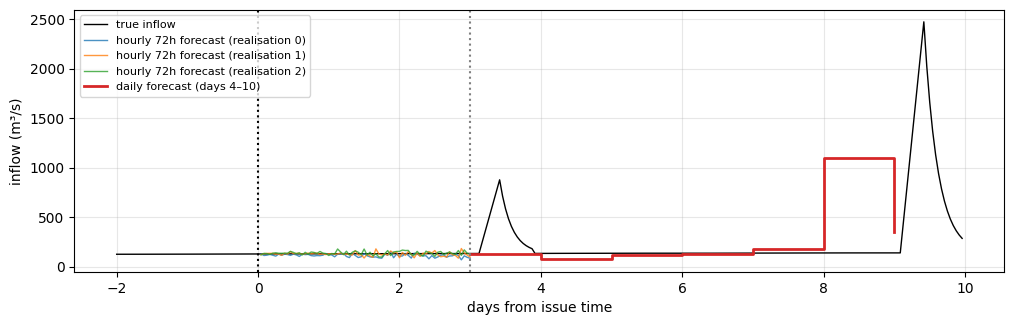

In [6]:
hfc, dfc = hr.make_forecasts(inflow, seed=0)
t0 = 185 * 24 + 6
fig, ax = plt.subplots()
ax.plot(np.arange(-48, 72 + 24 * 7) / 24, inflow[t0 - 48 : t0 + 72 + 24 * 7], "k", lw=1, label="true inflow")
for k, s in enumerate((0, 1, 2)):
    h2, _ = hr.make_forecasts(inflow, seed=s)
    ax.plot(np.arange(1, 73) / 24, h2[t0], lw=1, alpha=.8, label=f"hourly 72h forecast (realisation {k})")
ax.step(3 + np.arange(7), dfc[t0 // 24], where="post", c="tab:red", lw=2, label="daily forecast (days 4–10)")
ax.axvline(0, c="k", ls=":"); ax.axvline(3, c="grey", ls=":")
ax.set_xlabel("days from issue time"); ax.set_ylabel("inflow (m³/s)"); ax.legend(fontsize=8); ax.grid(alpha=.3)

Text(0.5, 1.0, 'hourly forecast skill')

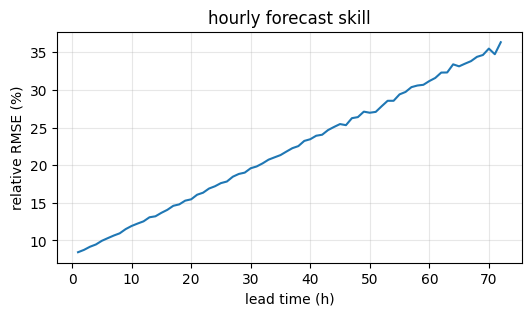

In [7]:
# forecast skill by lead time (relative RMSE)
rel = (hfc[:8000] / inflow[1:8001][:, None].repeat(72, 1) - 1)  # crude: compare lead-k forecast to truth at t+k
err = np.array([np.sqrt(np.mean((hfc[:8000 - k, k] / inflow[1 + k : 8001] - 1) ** 2)) for k in range(72)])
plt.figure(figsize=(6, 3)); plt.plot(np.arange(1, 73), 100 * err); plt.xlabel("lead time (h)"); plt.ylabel("relative RMSE (%)"); plt.grid(alpha=.3); plt.title("hourly forecast skill")

## 7. 실제 적용 시 교체할 데이터

| 이 노트북 | 실제 데이터 | 형식 |
|---|---|---|
| `LEVEL_TABLE`, `STORAGE_TABLE` | 댐 수위–저수량 곡선 | `level_m, storage_1e6m3` |
| `UPPER_GUIDE`, `LOWER_GUIDE` | 댐 운영 규정의 월별 상·하한 운영수위 | 12개 값 × 2 |
| `synthetic_hourly_inflow` | 시간 단위 실측 유입량 (≥10년) | `datetime, inflow_m3s` |
| `make_forecasts` | 기상예보 기반 유입량 예측 (72h hourly, 이후 daily) | `issue_time, lead, inflow_fc` |
| `LATERAL_RATIO`, `ROUTING_*` | 하류 주요지점 실측 유량과 도달시간 분석 | `datetime, ds_flow_m3s` |
| `Q_DS_SAFE`, `Q_ENV_MIN`, `RAMP_MAX` | 하천기본계획 계획홍수량, 하천유지유량, 방류 변화 규정 | 상수 |